## IdentifyOptimalClusterNumber
This script:
- Loads CLIP embeddings from the H5 data store and spatially joins points to LSOAs
- Cluster analysis:
    - Test whether there is a structure within the embeddings that would allow them to be broken down into sub-clusters
        - Silhouette scores
        - Elbow scores
        - Adjusted Rand Index
    - Decide on the optimal K
    - Run KMeans cluster analysis for K = 2..10
    - Save cluster assignments back to the H5 data store
- Examine the distribution of images across the IMD ranking scale, within each cluster
- Plot a sample of images associated with each cluster number
- Spatial plotting to check whether the distribution of clusters is even or uneven

In [1]:
import io
from math import ceil

import contextily as cx
import geopandas as gpd
import h5py
import pandas as pd
from PIL import Image
import umap

In [2]:
from clustering_functions import *
from directory_filepaths import *

print(f"Number of clusters (defined in clustering_functions.py) = {global_k}")
print(f"Will write outputs to {outputs_dir}")

Number of clusters (defined in clustering_functions.py) = 5
Will write outputs to ../outputs


In [3]:
# Load expanded dataframe (one row per image) produced by script 3
expanded_gdf = pd.read_pickle(os.path.join(data_dir, "one_row_per_image_cleaned.pkl"))
print(f"Loaded {len(expanded_gdf)} image rows")

Loaded 75586 image rows


# Test optimal cluster numbers

In [4]:
all_embeddings = np.stack(expanded_gdf['embedding'].values)
print(f"Embedding matrix shape: {all_embeddings.shape}")

Embedding matrix shape: (75586, 512)


### Examine silhouette scores

In [5]:
best_k, inertias, sil_scores = find_optimal_k_silhoutte_fast(all_embeddings)
print(best_k)

2


### Examine elbow scores

In [6]:
optimal_k, ks, inertias = find_optimal_k_elbow(all_embeddings)
# # plot_elbow(ks, inertias, optimal_k)


Detected elbow at k = 7


### Plot together elbow and silhouette scores

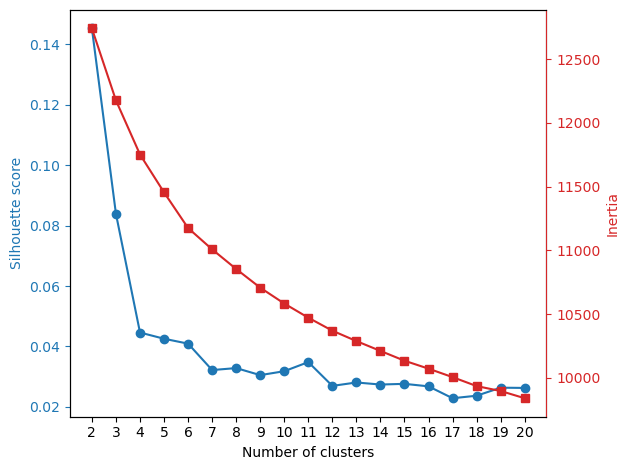

In [7]:
ks = range(2, 21)

fig, ax1 = plt.subplots(figsize=(10, 5))


# ----- Add title here -----
plt.title("Silhouette Score and Inertia for Number of Clusters")


# Silhouette scores (left axis, blue)
ax1.plot(ks, sil_scores, marker='o', color='tab:blue')
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette score", color='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax1.set_xticks(range(2, 21))

#ax1.axvline(best_k, linestyle='--', color='tab:blue', label=f'Best silhouette (k={best_k})')
#ax1.axvline(optimal_k, linestyle='--', color='tab:red', label=f'Elbow (k={optimal_k})')
#ax1.legend(loc='upper right')

# Inertia (right axis, red)
ax2 = ax1.twinx()
ax2.plot(ks, inertias, marker='s', color='tab:red')
ax2.set_ylabel("Inertia", color='tab:red')
ax2.tick_params(axis='y', colors='tab:red')
ax2.spines['right'].set_color('tab:red')

plt.tight_layout()

# Save to PDF
plt.savefig("cluster_diagnostics.pdf", format="pdf")

# Display on screen
plt.show()


### Assess clustering stability using the adjusted rand index

In [8]:
mean_aris = []
std_aris = []
for k in range(2,15):
    mean_ari, std_ari, _ = clustering_stability(all_embeddings, k)
    # print(f"k={k}: ARI = {mean_ari:.2f} ± {std_ari:.2f}")
    mean_aris.append(mean_ari)
    std_aris.append(std_ari)

Text(0, 0.5, 'ARI')

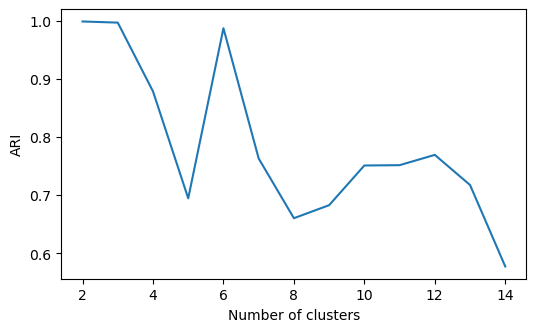

In [9]:
fig,ax=plt.subplots(figsize=(6,3.5))
ax.plot(range(2,15), mean_aris)
ax.set_xlabel("Number of clusters")
ax.set_ylabel("ARI")

# Run cluster analysis with optimal k
Add a column to the dataframe showing which cluster the image would fall within, for cluster numbers between 2 and 10

In [10]:
for k in range(2,11):
    #print(k)
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(all_embeddings)
    expanded_gdf[f'scene_cluster_{k}'] = labels + 1    

### Check UMAP low-dimensional projection

In [11]:
embeddings = np.vstack(expanded_gdf["embedding"].values)   # shape (N, 512)
             # string labels
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',   # recommended for CLIP embeddings
    random_state=RANDOM_STATE)

emb_2d = reducer.fit_transform(embeddings)  # shape (N, 2)

expanded_gdf['umap_x'] = emb_2d[:, 0]
expanded_gdf['umap_y'] = emb_2d[:, 1]

/opt/homebrew/anaconda3/envs/integrate/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Plot (this code is SLOW)

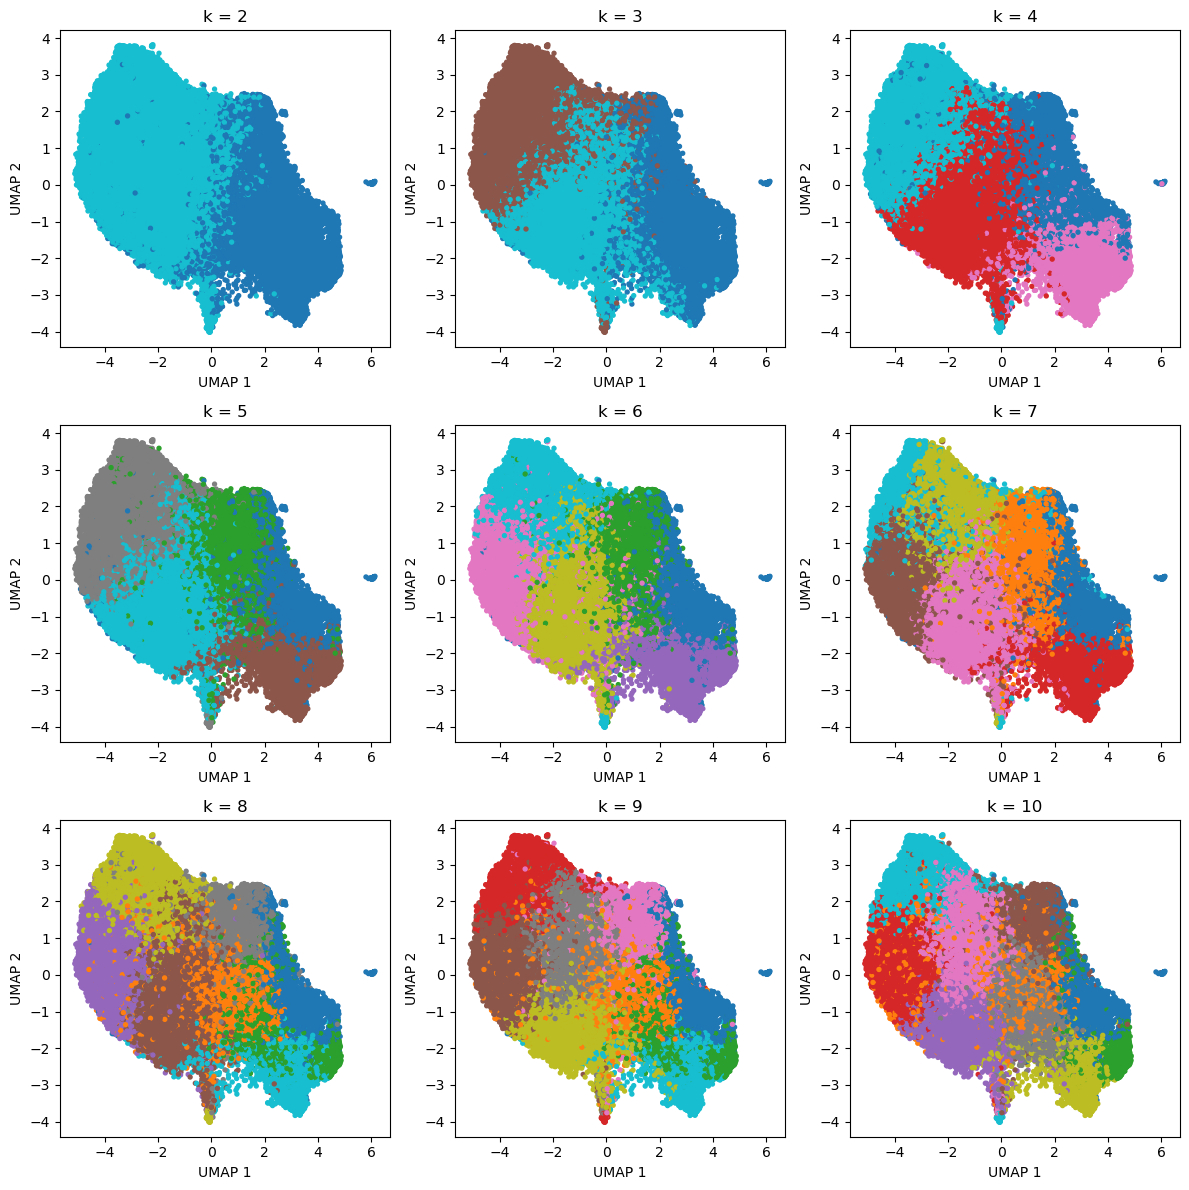

In [12]:
ks = range(2, 11)  # k = 2 to 10
n_plots = len(ks)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axs = axs.flatten()

for i, k in enumerate(ks):
    ax = axs[i]
    labels = expanded_gdf[f'scene_cluster_{k}']

    sc = ax.scatter(expanded_gdf['umap_x'], expanded_gdf['umap_y'], c=labels, cmap='tab10', s=8)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

# Turn off any unused axes
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

### Save

In [13]:
expanded_gdf.to_pickle(data_dir + f"one_row_per_image_cleaned_with_cluster_numbers.pkl")

In [14]:
# for num in range(1,8):
#     print(num)
#     print(len(expanded_gdf[expanded_gdf['scene_cluster_7']==num]))

### Check the images in each cluster

In [ ]:
total_k = global_k  # k defined in clustering_functions.py
n_images = 70
cols = 7

with h5py.File(h5_filename, "r") as f:
    h5_point_ids = f["point_id"][:]
    h5_image_paths = f["image_paths"][:]
    images_jpeg = f["images_jpeg"]

    # point_id values have gaps (0..19195), so they don't equal H5 row indices (0..18896)
    pid_to_h5row = {int(pid): i for i, pid in enumerate(h5_point_ids)}

    for this_cluster_num in range(1, total_k + 1):
        this_cluster = expanded_gdf[expanded_gdf[f"scene_cluster_{total_k}"] == this_cluster_num]
        sample = this_cluster.sample(n=min(n_images, len(this_cluster)), random_state=RANDOM_STATE)

        images = []
        for _, row in sample.iterrows():
            h5_row = pid_to_h5row.get(int(row["point_id"]))
            if h5_row is None:
                continue
            target_path = row["image_path"]

            for slot in range(4):
                stored = h5_image_paths[h5_row, slot].decode("ascii").rstrip("\x00")
                if stored == target_path:
                    jpeg_bytes = images_jpeg[h5_row, slot]
                    if isinstance(jpeg_bytes, np.void):
                        jpeg_bytes = jpeg_bytes.tobytes()
                    images.append(Image.open(io.BytesIO(jpeg_bytes)).convert("RGB"))
                    break

        if not images:
            print(f"Cluster {this_cluster_num}: no images matched, skipping")
            continue

        n_rows = ceil(len(images) / cols)
        fig, axes = plt.subplots(n_rows, cols, figsize=(cols * 2, n_rows * 2))
        axes = axes.flatten()

        for ax, img in zip(axes, images):
            ax.imshow(img)
            ax.axis('off')
        for ax in axes[len(images):]:
            ax.axis('off')

        fig.suptitle(f"Cluster {this_cluster_num} (k={total_k})", y=1.005)
        plt.tight_layout()
        plt.show()

## Examine distribution of images in each cluster across IMD (re) ranks

In [16]:
# imd_file is imported from directory_filepaths
imd = pd.read_excel(imd_file, sheet_name="IoD2025 Domains", header=0)

imd = imd.rename(columns={
    "LSOA code (2021)": "LSOA21CD",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)": "imd_decile",
})

# Filter to LSOAs present in our dataset
lsoa21cds = expanded_gdf["LSOA21CD"].unique()
imd_manc = imd[imd["LSOA21CD"].isin(lsoa21cds)].copy()

# Add a local re-ranking for Manchester only
imd_manc['imd_rerank'] = imd_manc['imd_rank'].rank(method='first').astype(int)

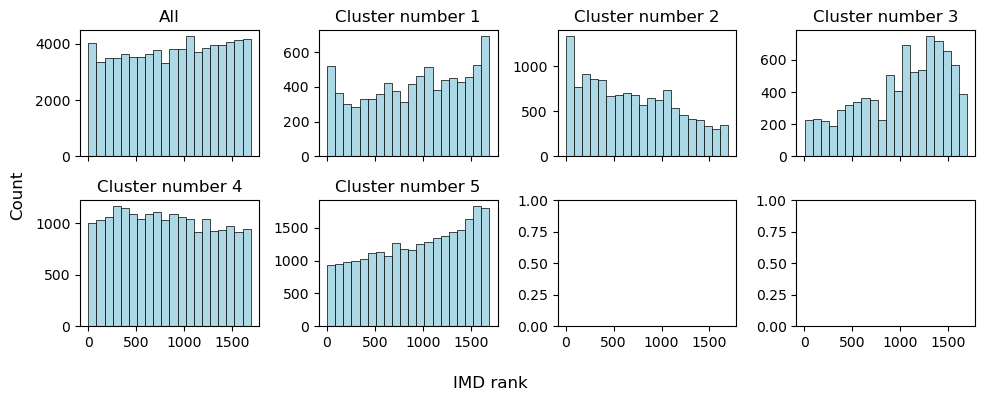

In [17]:
expanded_gdf_with_imd = pd.merge(left=expanded_gdf, right=imd_manc[['LSOA21CD', 'imd_rank', 'imd_rerank']], on="LSOA21CD")

imd_column = 'imd_rerank' #'imd_rank'

fig, axs = plt.subplots(ncols=4, nrows=2,sharex=True, sharey=False,figsize=(10, 4))
axs = axs.flatten()

axs[0].hist(expanded_gdf_with_imd[imd_column],bins=20,edgecolor="black",linewidth=0.5,color="lightblue")
axs[0].set_title("All")

for cluster_number in range(1, total_k+1):
    cluster = expanded_gdf_with_imd[expanded_gdf_with_imd[f"scene_cluster_{total_k}"] == cluster_number]
    axs[cluster_number].hist(cluster[imd_column], bins=20, edgecolor="black",linewidth=0.5, color="lightblue")
    axs[cluster_number].set_title(f"Cluster number {cluster_number}")

# # Switch off any unused axes
# for ax in axs[7:]:
#     ax.axis("off")

# Global labels
fig.supxlabel("IMD rank")
fig.supylabel("Count")

plt.tight_layout()

# Spatial plots

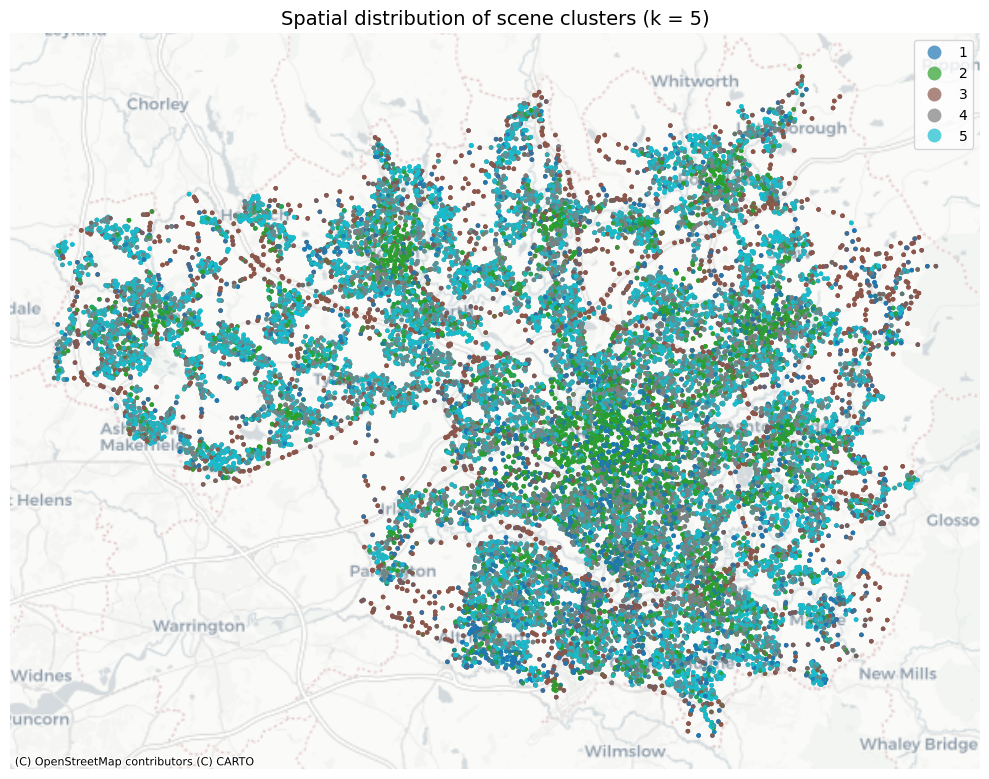

In [18]:
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    expanded_gdf,
    geometry=gpd.points_from_xy(
        expanded_gdf.longitude,
        expanded_gdf.latitude),
    crs="EPSG:4326")#  # WGS84)
gdf = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column=f"scene_cluster_{total_k}",
    categorical=True,
    legend=True,
    markersize=5,
    alpha=0.7)

# Add basemap
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
ax.set_title(f"Spatial distribution of scene clusters (k = {total_k})", fontsize=14)

plt.tight_layout()
fig.savefig(os.path.join(outputs_dir, "5-cluster_spatial_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()